In [ ]:
! pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yasir90
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset


100%|██████████| 380M/380M [00:01<00:00, 229MB/s]


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

TRAIN_PATH = "/content/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset"
TEST_PATH = "/content/augmented-alzheimer-mri-dataset/OriginalDataset"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.
Found 6400 images belonging to 4 classes.


In [6]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

In [7]:
x = Conv2D(32,(3,3),padding="same")(input_layer)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(128,(3,3),padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling2D()(x)

cnn_output = GlobalAveragePooling2D()(x)

In [8]:
vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=input_layer
)

for layer in vgg.layers:
    layer.trainable = False

vgg_output = GlobalAveragePooling2D()(vgg.output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
fusion = Concatenate()([cnn_output, vgg_output])

In [10]:
x = Reshape((1, fusion.shape[-1]))(fusion)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=64
)(x, x)

x = Add()([x, attention])
x = LayerNormalization()(x)

ffn = Dense(256, activation="relu")(x)
ffn = Dense(x.shape[-1])(ffn)

x = Add()([x, ffn])
x = LayerNormalization()(x)

transformer_output = Flatten()(x)

In [11]:
x = Dense(256, activation="relu")(transformer_output)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

In [12]:
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0

 Total params: 15,995,268 (61.02 MB)

 Trainable params: 1,279,620 (4.88 MB)

 Non-trainable params: 14,715,648 (56.14 MB)

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [14]:
for layer in vgg.layers[-8:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 568s 627ms/step - accuracy: 0.3558 - loss: 1.7534 - val_accuracy: 0.5762 - val_loss: 1.3622
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 495s 582ms/step - accuracy: 0.5985 - loss: 1.1324 - val_accuracy: 0.7444 - val_loss: 0.8252
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 495s 582ms/step - accuracy: 0.6904 - loss: 0.9458 - val_accuracy: 0.8040 - val_loss: 0.7122
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 489s 575ms/step - accuracy: 0.7607 - loss: 0.8251 - val_accuracy: 0.7190 - val_loss: 0.8471
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 493s 580ms/step - accuracy: 0.8152 - loss: 0.7447 - val_accuracy: 0.8050 - val_loss: 0.7416
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 491s 578ms/step - accuracy: 0.8514 - loss: 0.6815 - val_accuracy: 0.8402 - val_loss: 0.6725
Epoch 7/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 491s 578ms/step - accuracy: 0.8815 - loss: 0.6288 - val_accuracy: 0.8081 - val_loss: 0.7397
Epoch 8/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 490s 577ms/step - accuracy: 0.9011 -

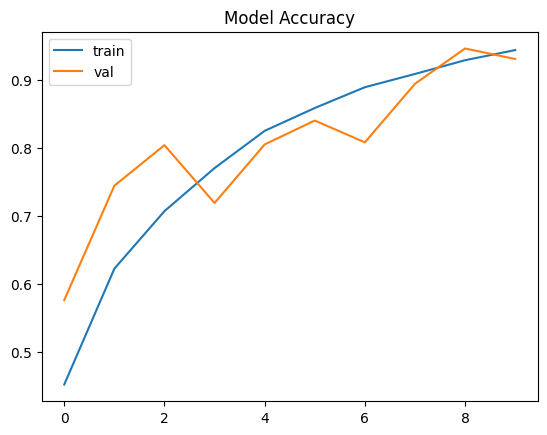

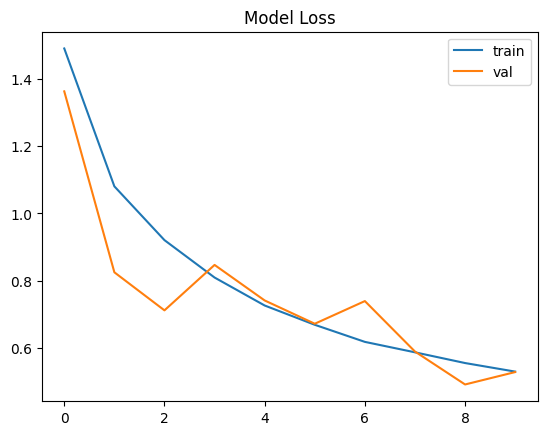

In [17]:
plt.plot(history_fine.history["accuracy"])
plt.plot(history_fine.history["val_accuracy"])
plt.title("Model Accuracy")
plt.legend(["train","val"])
plt.show()

plt.plot(history_fine.history["loss"])
plt.plot(history_fine.history["val_loss"])
plt.title("Model Loss")
plt.legend(["train","val"])
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 207ms/step - accuracy: 0.9860 - loss: 0.4251
Test Accuracy: 0.9764062762260437


In [19]:
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)
print(cm)

200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 204ms/step
[[ 893    0    1    2]
 [   0   64    0    0]
 [  15    0 3145   40]
 [  13    0   80 2147]]


In [20]:
print(classification_report(true_classes, pred_classes, target_names=class_labels))

                  precision    recall  f1-score   support

    MildDemented       0.97      1.00      0.98       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.97      0.98      0.98      3200
VeryMildDemented       0.98      0.96      0.97      2240

        accuracy                           0.98      6400
       macro avg       0.98      0.98      0.98      6400
    weighted avg       0.98      0.98      0.98      6400



In [21]:
model.save("alzheimer_model.h5")

In [22]:
import json

class_indices = train_data.class_indices

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("JSON file saved!")

JSON file saved!


In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names (dataset অনুযায়ী)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# image path
img_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/VeryMildDemented/26 (58).jpg"

# load image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension (model input shape)
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
predicted_class = class_names[np.argmax(prediction)]

# confidence
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: VeryMildDemented
Confidence: 0.7142831


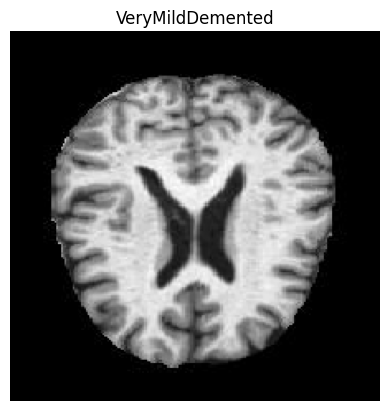

In [26]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()

In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names (dataset অনুযায়ী)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# image path
img_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/ModerateDemented/moderateDem28.jpg"

# load image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension (model input shape)
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
predicted_class = class_names[np.argmax(prediction)]

# confidence
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: ModerateDemented
Confidence: 0.956786


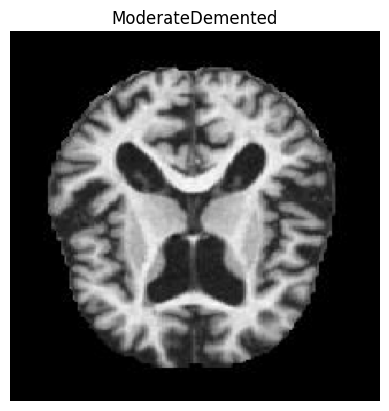

In [28]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()

In [29]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names (dataset অনুযায়ী)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# image path
img_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/MildDemented/28 (26).jpg"

# load image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension (model input shape)
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
predicted_class = class_names[np.argmax(prediction)]

# confidence
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediction: MildDemented
Confidence: 0.98087513


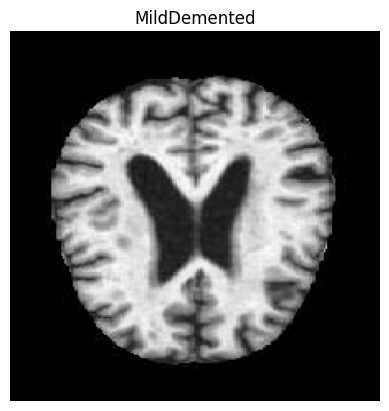

In [30]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()

In [31]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names (dataset অনুযায়ী)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# image path
img_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/NonDemented/27 (19).jpg"

# load image
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension (model input shape)
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
predicted_class = class_names[np.argmax(prediction)]

# confidence
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prediction: NonDemented
Confidence: 0.93554467


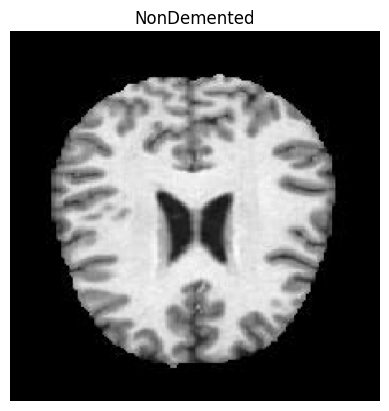

In [32]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")
plt.show()

In [33]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [35]:
IMG_SIZE = 224

img_path = "/content/augmented-alzheimer-mri-dataset/OriginalDataset/NonDemented/27 (17).jpg"

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

In [36]:
last_conv_layer_name = "block5_conv3"

In [37]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [38]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [39]:
img = cv2.imread(img_path)

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

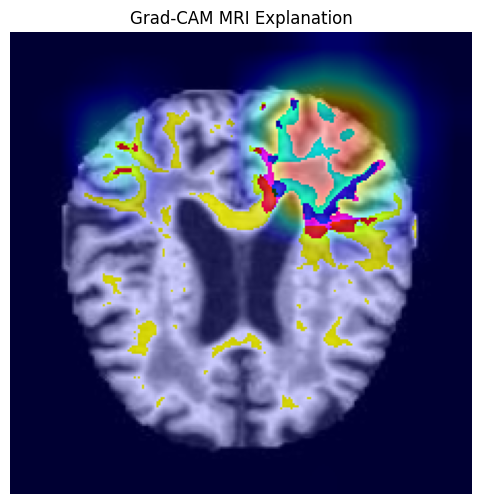

In [40]:
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.title("Grad-CAM MRI Explanation")

plt.show()